In [1]:
# Cell 1: Setup — chạy 1 lần duy nhất
import os
import sys

# Đảm bảo CWD = project root (quan trọng cho relative paths)
PROJECT_ROOT = r"R:\_Projects\Eurus_Workspace\HolmHz"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

print(f"CWD: {os.getcwd()}")

CWD: R:\_Projects\Eurus_Workspace\HolmHz


In [2]:
# Cell 2: Import libraries
import matplotlib.pyplot as plt
import numpy as np
import torch

from holmhz.data import (
    ImageDataset,
    create_dataloader,
    get_dataset_info,
    get_train_transforms,
    get_val_transforms,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

print("✅ Imports done")

r:\_Projects\Eurus_Workspace\HolmHz\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports done


In [3]:
# Cell 3: Dataset info — xem tổng quan split results
for split_name, path in [
    ("Train", "data/manifests/train.json"),
    ("Val", "data/manifests/val.json"),
    ("Test ID", "data/manifests/test_id.json"),
    ("Test OOD", "data/manifests/test_ood.json"),
]:
    info = get_dataset_info(path)
    print(f"{split_name:10s}: {info['total']:6d} ảnh | {info['label_ratio']} | sources: {list(info['sources'].keys())}")

Train     :  18550 ảnh | 45.4% real / 54.6% fake | sources: ['stylegan', 'cifake', 'ffhq', 'sd15']
Val       :   3975 ảnh | 44.7% real / 55.3% fake | sources: ['stylegan', 'ffhq', 'cifake', 'sd15']
Test ID   :   3975 ảnh | 45.2% real / 54.8% fake | sources: ['cifake', 'sd15', 'ffhq', 'stylegan']
Test OOD  :   1180 ảnh | 50.8% real / 49.2% fake | sources: ['flux', 'real_camera', 'real_pexels', 'tristanzhang_fake']


In [4]:
# Cell 4: Load 1 batch — verify pipeline hoạt động
loader = create_dataloader("data/manifests/val.json", batch_size=32, is_training=False, num_workers=0)
batch = next(iter(loader))

print(f"Batch image shape : {batch['image'].shape}")    # [32, 3, 224, 224]
print(f"Batch label shape : {batch['label'].shape}")     # [32]
print(f"Image dtype       : {batch['image'].dtype}")     # float32
print(f"Image range       : [{batch['image'].min():.2f}, {batch['image'].max():.2f}]")
print(f"Labels (first 8)  : {batch['label'][:8].tolist()}")
print(f"Sources (first 4) : {batch['source'][:4]}")
print("\n✅ Data pipeline working!")

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])
Image dtype       : torch.float32
Image range       : [-2.12, 2.64]
Labels (first 8)  : [1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Sources (first 4) : ['stylegan', 'ffhq', 'cifake', 'sd15']

✅ Data pipeline working!


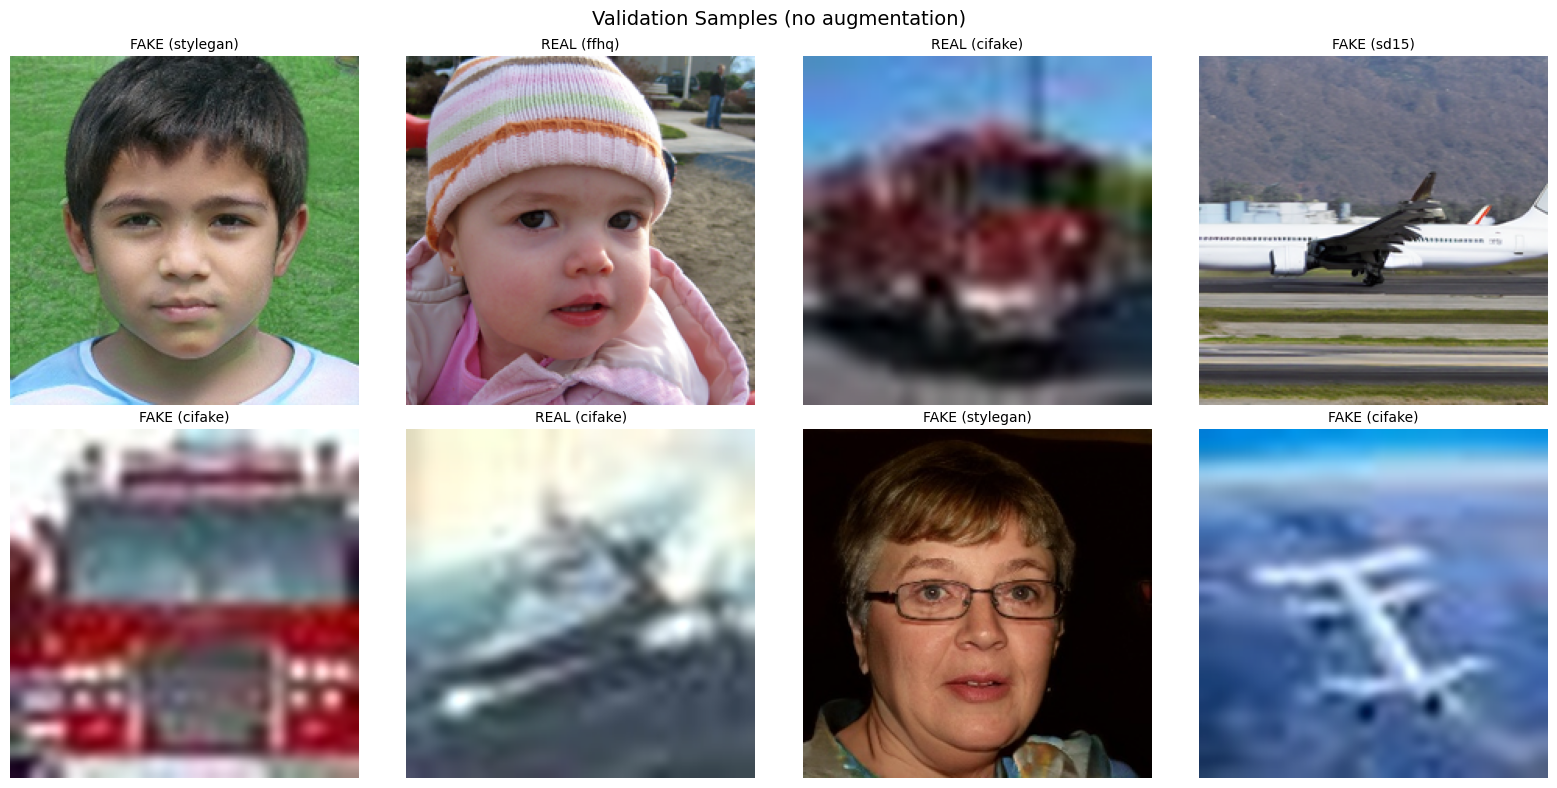

✅ Saved to outputs/sample_batch_val.png


In [5]:
# Cell 5: Visualize sample images (train — có augmentation)
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Đảo ngược normalize để hiển thị ảnh."""
    img = tensor.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()  # [C,H,W] → [H,W,C]

# Dùng val.json (nhẹ hơn train.json) — chỉ cần 8 ảnh
ds = ImageDataset("data/manifests/val.json", transform=get_val_transforms())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    sample = ds[i]
    img = denormalize(sample["image"])
    label = "REAL" if sample["label"] == 0 else "FAKE"
    source = sample["source"]
    ax.imshow(img)
    ax.set_title(f"{label} ({source})", fontsize=10)
    ax.axis("off")
plt.suptitle("Validation Samples (no augmentation)", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/sample_batch_val.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to outputs/sample_batch_val.png")

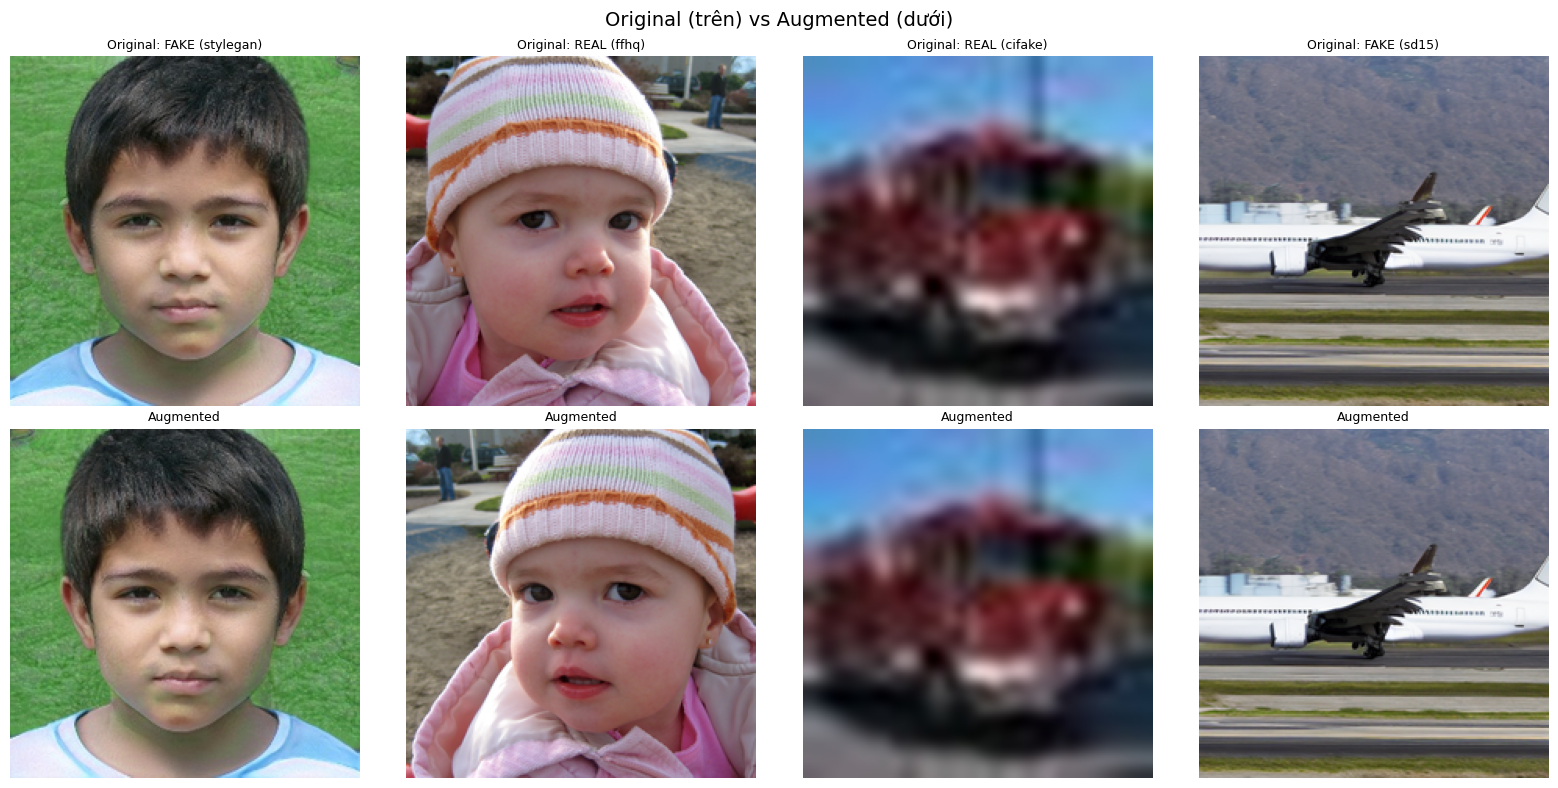

✅ Saved to outputs/sample_augmented_vs_original.png


In [6]:
# Cell 6: So sánh augmented vs original (cùng 1 ảnh)
ds_aug = ImageDataset("data/manifests/val.json", transform=get_train_transforms())
ds_orig = ImageDataset("data/manifests/val.json", transform=get_val_transforms())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Original (no augmentation)
    orig = ds_orig[i]
    axes[0, i].imshow(denormalize(orig["image"]))
    label = "REAL" if orig["label"] == 0 else "FAKE"
    axes[0, i].set_title(f"Original: {label} ({orig['source']})", fontsize=9)
    axes[0, i].axis("off")

    # Augmented
    aug = ds_aug[i]
    axes[1, i].imshow(denormalize(aug["image"]))
    axes[1, i].set_title(f"Augmented", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Original (trên) vs Augmented (dưới)", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/sample_augmented_vs_original.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to outputs/sample_augmented_vs_original.png")